<a href="https://colab.research.google.com/github/Asechsa/Customer_Churn_Predict/blob/main/FINAL_PROJECT_SASKA_AULISECHA_51424273_2IA01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FINAL PROJECT BOOTCAMP DATA SCIENCE**


*   **NAMA  : SASKA AULISECHA**
*   **NPM   : 51424273**
*   **KELAS : 2IA01**



#**CUSTOMER CHURN PREDICTION**
## Memenuhi 3 Traget wajib :


1. **Deteksi Profil pelanggan berisiko tinggi churn**
2.   **Penanganan class imbalance secara saintifik (SMOTE)**
3. **Recall >=80% pada Test Set**






In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, recall_score, precision_score,
                             f1_score, roc_auc_score)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

## **DATA UNDERSTANDING**

In [ ]:
url = "https://raw.githubusercontent.com/ahmadluay9/Customer-Churn-Prediction/main/churn.csv"
df = pd.read_csv(url)

In [ ]:
print(f'Shape Dataset : {df.shape}')
df.info()
print(f'\nStatistik deskriptif:')
print(df.describe())
print(f'\nMissing values :')
print(df.isnull().sum()[df.isnull().sum()>0])

Shape Dataset : (37010, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37010 entries, 0 to 37009
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   user_id                       37010 non-null  object 
 1   age                           37010 non-null  int64  
 2   gender                        36951 non-null  object 
 3   region_category               31579 non-null  object 
 4   membership_category           37010 non-null  object 
 5   joining_date                  37010 non-null  object 
 6   joined_through_referral       31568 non-null  object 
 7   preferred_offer_types         36722 non-null  object 
 8   medium_of_operation           31615 non-null  object 
 9   internet_option               37010 non-null  object 
 10  last_visit_time               37010 non-null  object 
 11  days_since_last_login         37010 non-null  int64  
 12  avg_time_spent                37

churn_risk_score
1    20018
0    16992
Name: count, dtype: int64
churn_risk_score
1    54.088084
0    45.911916
Name: proportion, dtype: float64


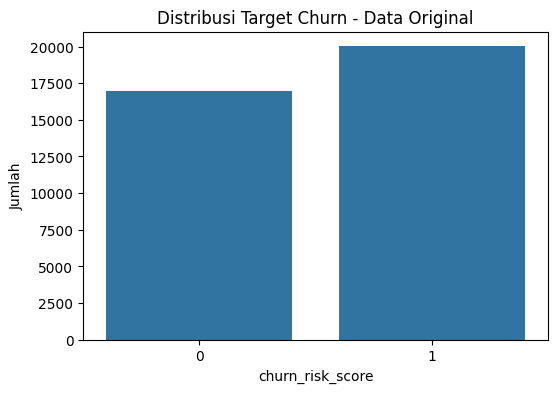

In [ ]:
#Distribusi target
print(df['churn_risk_score'].value_counts())
print(df['churn_risk_score'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(x='churn_risk_score', data=df)
plt.title("Distribusi Target Churn - Data Original")
plt.ylabel("Jumlah")
plt.show()

In [ ]:
#Menganalisis ketidakseimbangan kelas
imbalance_ratio = df['churn_risk_score'].value_counts()[0] / df['churn_risk_score'].value_counts()[1]
print(f"\nImbalance Ratio (mayoritas/minoritas): {imbalance_ratio:.2f}")
print("Kesimpulan: Terdapat moderate class imbalance yang WAJIB ditangani secara saintifik.")


Imbalance Ratio (mayoritas/minoritas): 0.85
Kesimpulan: Terdapat moderate class imbalance yang WAJIB ditangani secara saintifik.


## **DATA CLEANING & PREPROCESSING**

In [ ]:
#Copy data
df_clean = df.copy()

In [ ]:
#Drop kolom yang tidak relevan
df_clean = df_clean.drop(['user_id','last_visit_time'],axis=1,errors='ignore')

In [ ]:
# Handle missing values - imputasi dengan modus
categorical_cols = ['gender','region_category','joined_through_referral','preferred_offer_types','medium_of_operation']
for col in categorical_cols:
  if col in df_clean.columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    print(f"Missing value '{col}'diisi dengan modus :'{df_clean[col].mode()[0]}'")

Missing value 'gender'diisi dengan modus :'F'
Missing value 'region_category'diisi dengan modus :'Town'
Missing value 'joined_through_referral'diisi dengan modus :'No'
Missing value 'preferred_offer_types'diisi dengan modus :'Gift Vouchers/Coupons'
Missing value 'medium_of_operation'diisi dengan modus :'Desktop'


In [ ]:
# Konversi kolom tanggal
if 'joining_date' in df_clean.columns:
    df_clean['joining_date'] = pd.to_datetime(df_clean['joining_date'])
    reference_date = pd.Timestamp('2024-01-01')
    df_clean['tenure_days'] = (reference_date - df_clean['joining_date']).dt.days
    df_clean = df_clean.drop('joining_date', axis=1)
    print("Kolom 'joining_date' dikonversi menjadi 'tenure_days'")

Kolom 'joining_date' dikonversi menjadi 'tenure_days'


In [ ]:
#Verifikasi tidak ada missing value
print(f"\nMissing value setelah cleaning : {df_clean.isnull().sum().sum()}")


Missing value setelah cleaning : 0


## **EXPLORATORY DATA ANALYSIS (EDA)**

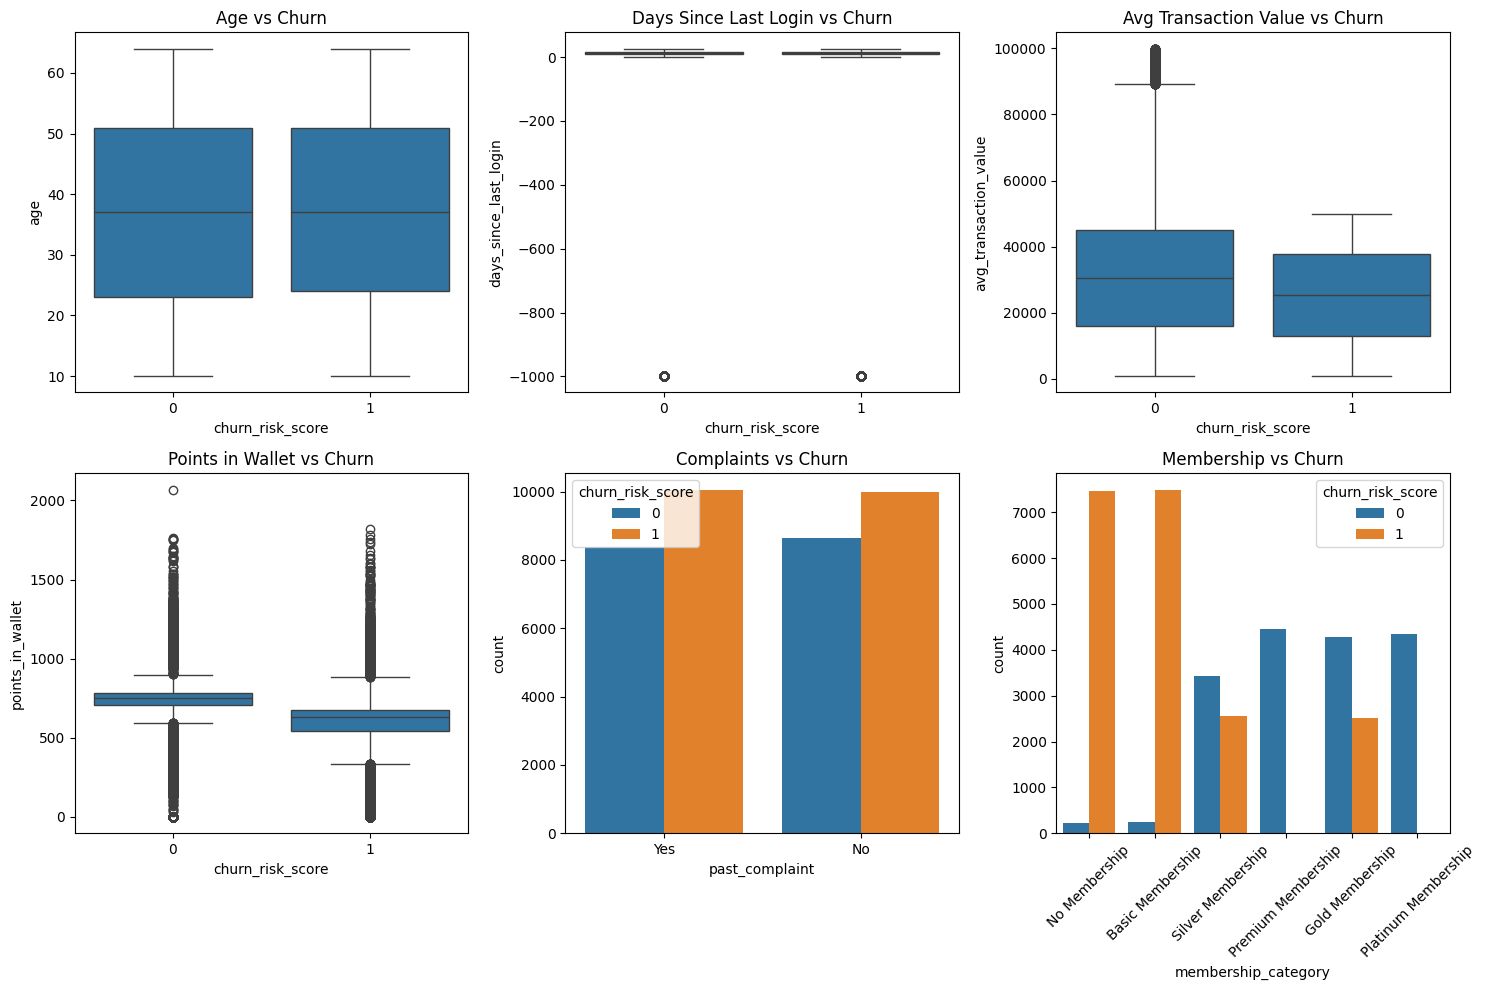

In [ ]:
#Analisis umur vs churn
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
sns.boxplot(x='churn_risk_score', y='age', data=df_clean, ax=axes[0,0])
axes[0,0].set_title('Age vs Churn')
#Analisis Days Since Last Login vs Churn
sns.boxplot(x='churn_risk_score', y='days_since_last_login', data=df_clean, ax=axes[0,1])
axes[0,1].set_title('Days Since Last Login vs Churn')
#Analisis Avg Transaction Value vs Churn
sns.boxplot(x='churn_risk_score', y='avg_transaction_value', data=df_clean, ax=axes[0,2])
axes[0,2].set_title('Avg Transaction Value vs Churn')
#Analisis Points in Wallet vs Churn
sns.boxplot(x='churn_risk_score', y='points_in_wallet', data=df_clean, ax=axes[1,0])
axes[1,0].set_title('Points in Wallet vs Churn')
#Analisis Complaints vs Churn
sns.countplot(x='past_complaint', hue='churn_risk_score', data=df_clean, ax=axes[1,1])
axes[1,1].set_title('Complaints vs Churn')
#Analisis Membership vs Churn
sns.countplot(x='membership_category', hue='churn_risk_score', data=df_clean, ax=axes[1,2])
axes[1,2].set_title('Membership vs Churn')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

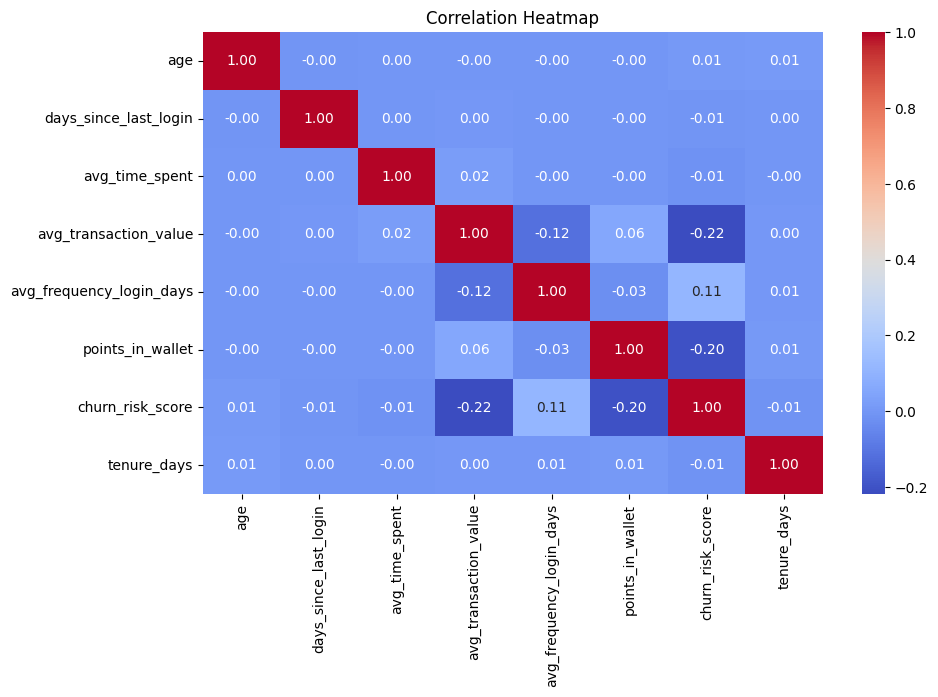

In [ ]:
# Korelasi numerik
plt.figure(figsize=(10,6))
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
correlation = df_clean[numeric_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
#Encoding
categorical_features = df_clean.select_dtypes(include=['object']).columns.tolist()
categorical_features = [col for col in categorical_features if col != 'churn_risk_score']

print(f"Fitur kategorikal yang akan di-encode: {categorical_features}")

df_encoded = pd.get_dummies(df_clean, columns=categorical_features, drop_first=True)
print(f"Shape setelah encoding: {df_encoded.shape}")

Fitur kategorikal yang akan di-encode: ['gender', 'region_category', 'membership_category', 'joined_through_referral', 'preferred_offer_types', 'medium_of_operation', 'internet_option', 'used_special_discount', 'offer_application_preference', 'past_complaint', 'complaint_status', 'feedback']
Shape setelah encoding: (37010, 38)


## **MODELING & EVALUATION**

In [ ]:
# Split data
X = df_encoded.drop('churn_risk_score', axis=1)
y = df_encoded['churn_risk_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data Train:", X_train.shape)
print("Data Test :", X_test.shape)

Data Train: (29608, 37)
Data Test : (7402, 37)


In [ ]:
# Setup Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'recall', 'precision', 'f1', 'roc_auc']

In [ ]:
# MODEL 1 : LOGISTIC REGRESSION + SMOTE +SCALING
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=2000, random_state=42))
])

# Cross Validation
cv_results_lr = cross_validate(pipeline_lr, X_train, y_train, cv=cv,
                                scoring=scoring)

print("Logistic Regression - 5-Fold CV Results:")
print(f"  Accuracy : {cv_results_lr['test_accuracy'].mean():.4f}")
print(f"  Recall   : {cv_results_lr['test_recall'].mean():.4f}")
print(f"  Precision: {cv_results_lr['test_precision'].mean():.4f}")
print(f"  F1-Score : {cv_results_lr['test_f1'].mean():.4f}")
print(f"  ROC-AUC  : {cv_results_lr['test_roc_auc'].mean():.4f}")

# Fit & Predict
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
y_proba_lr = pipeline_lr.predict_proba(X_test)[:, 1]

Logistic Regression - 5-Fold CV Results:
  Accuracy : 0.8520
  Recall   : 0.7889
  Precision: 0.9265
  F1-Score : 0.8522
  ROC-AUC  : 0.9497


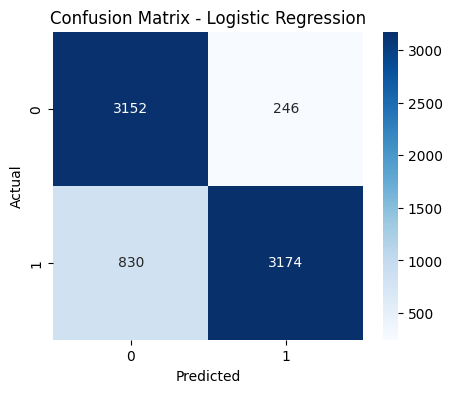

In [ ]:
# Confusion Matrix - Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Classification Report - Logistic Regression
print("=== Logistic Regression - Test Set ===")
print(classification_report(y_test, y_pred_lr))
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")

=== Logistic Regression - Test Set ===
              precision    recall  f1-score   support

           0       0.79      0.93      0.85      3398
           1       0.93      0.79      0.86      4004

    accuracy                           0.85      7402
   macro avg       0.86      0.86      0.85      7402
weighted avg       0.87      0.85      0.85      7402

Recall: 0.7927


## **MODEL 2 : RANDOM FOREST + SMOTE**

In [ ]:
pipeline_rf = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# Cross Validation
cv_results_rf = cross_validate(pipeline_rf, X_train, y_train, cv=cv,
                                scoring=scoring)

print("Random Forest - 5-Fold CV Results:")
print(f"  Accuracy : {cv_results_rf['test_accuracy'].mean():.4f}")
print(f"  Recall   : {cv_results_rf['test_recall'].mean():.4f}")
print(f"  Precision: {cv_results_rf['test_precision'].mean():.4f}")
print(f"  F1-Score : {cv_results_rf['test_f1'].mean():.4f}")
print(f"  ROC-AUC  : {cv_results_rf['test_roc_auc'].mean():.4f}")

# Fit & Predict
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

Random Forest - 5-Fold CV Results:
  Accuracy : 0.9299
  Recall   : 0.9445
  Precision: 0.9273
  F1-Score : 0.9358
  ROC-AUC  : 0.9735


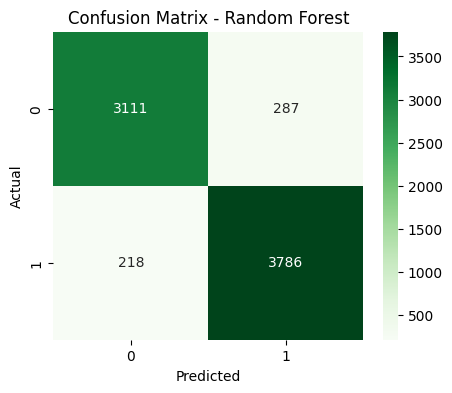

In [ ]:
# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Classification Report - Random Forest
print("=== Random Forest - Test Set ===")
print(classification_report(y_test, y_pred_rf))
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")

=== Random Forest - Test Set ===
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      3398
           1       0.93      0.95      0.94      4004

    accuracy                           0.93      7402
   macro avg       0.93      0.93      0.93      7402
weighted avg       0.93      0.93      0.93      7402

Recall: 0.9456


In [ ]:
# Feature Importance - Random Forest
rf_model = pipeline_rf.named_steps['classifier']
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Top 10 Feature Importance
importance.head(10)

,Feature,Importance
5,points_in_wallet,0.367085
12,membership_category_Platinum Membership,0.106505
13,membership_category_Premium Membership,0.104734
11,membership_category_No Membership,0.082589
3,avg_transaction_value,0.048471
10,membership_category_Gold Membership,0.030369
14,membership_category_Silver Membership,0.026380
6,tenure_days,0.023300
2,avg_time_spent,0.022859
0,age,0.019909


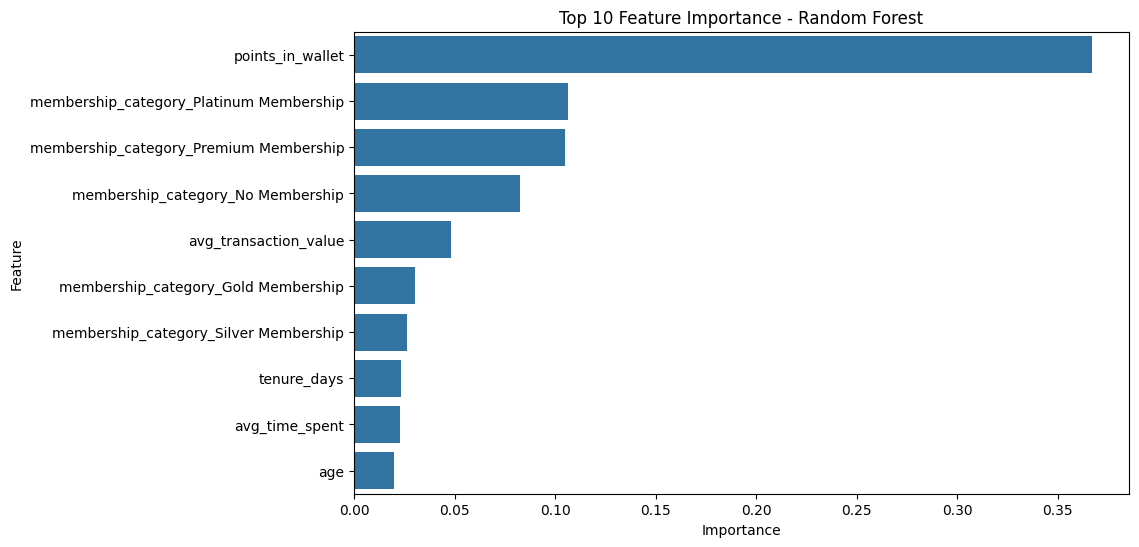

In [ ]:
# Visualisasi Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Feature Importance - Random Forest')
plt.show()

In [ ]:
# Perbandingan Model
result = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'F1-Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf)],
    'ROC-AUC': [roc_auc_score(y_test, y_proba_lr), roc_auc_score(y_test, y_proba_rf)]
})

result

,Model,Accuracy,Recall,Precision,F1-Score,ROC-AUC
0,Logistic Regression,0.854634,0.792707,0.928070,0.855065,0.955572
1,Random Forest,0.931775,0.945554,0.929536,0.937477,0.977012


## **BAGIAN 5: INSIGHT & CONCLUSION**

In [ ]:
print("""
# Target 1: Profil Pelanggan Berisiko Tinggi Churn
Berdasarkan Feature Importance (Random Forest), pelanggan
berisiko churn memiliki karakteristik:

1. points_in_wallet RENDAH → Tidak terikat loyalty program
2. avg_transaction_value RENDAH → Engagement menurun
3. avg_frequency_login_days TINGGI → Jarang login
4. days_since_last_login TINGGI → Lama tidak aktif
5. past_complaint = YA → Ada keluhan tidak terselesaikan
6. tenure_days (masa langganan) berpengaruh signifikan
7. membership_category PREMIUM/PLATINUM → Ekspektasi tinggi

Target 2: Penanganan Class Imbalance

* SMOTE (Synthetic Minority Over-sampling) diterapkan
* Dalam Pipeline untuk mencegah data leakage
* Validasi dengan Stratified 5-Fold Cross Validation

# Target 3: Recall >= 80%

""")

# Cek threshold
recall_lr = recall_score(y_test, y_pred_lr)
recall_rf = recall_score(y_test, y_pred_rf)

print(f"Logistic Regression Recall: {recall_lr:.2%} → {'MEMENUHI' if recall_lr >= 0.80 else 'TIDAK MEMENUHI'}")
print(f"Random Forest Recall      : {recall_rf:.2%} → {'MEMENUHI' if recall_rf >= 0.80 else 'TIDAK MEMENUHI'}")

print(f"""
MODEL TERBAIK: Random Forest
   Recall = {recall_rf:.2%} (melebihi threshold 80%)

# REKOMENDASI BISNIS:
1. Program loyalty untuk pelanggan dengan poin rendah
2. Tindak lanjut prioritas untuk pelanggan dengan keluhan
3. Notifikasi re-engagement untuk pelanggan lama tidak login
4. Special offer untuk pelanggan dengan transaksi menurun
""")


# Target 1: Profil Pelanggan Berisiko Tinggi Churn
Berdasarkan Feature Importance (Random Forest), pelanggan
berisiko churn memiliki karakteristik:

1. points_in_wallet RENDAH → Tidak terikat loyalty program
2. avg_transaction_value RENDAH → Engagement menurun
3. avg_frequency_login_days TINGGI → Jarang login
4. days_since_last_login TINGGI → Lama tidak aktif
5. past_complaint = YA → Ada keluhan tidak terselesaikan
6. tenure_days (masa langganan) berpengaruh signifikan
7. membership_category PREMIUM/PLATINUM → Ekspektasi tinggi

Target 2: Penanganan Class Imbalance

* SMOTE (Synthetic Minority Over-sampling) diterapkan
* Dalam Pipeline untuk mencegah data leakage
* Validasi dengan Stratified 5-Fold Cross Validation

# Target 3: Recall >= 80%


Logistic Regression Recall: 79.27% → TIDAK MEMENUHI
Random Forest Recall      : 94.56% → MEMENUHI

MODEL TERBAIK: Random Forest
   Recall = 94.56% (melebihi threshold 80%)

# REKOMENDASI BISNIS:
1. Program loyalty untuk pelanggan dengan poin ren